In [136]:
#######################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)            #
# E-mail: wgomez@cinvestav.mx                         #
# Curso:   Análisis de datos                          #
# Tópico:  Clasificador de los k-vecinos más cercanos #
#######################################################

Carga bibliotecas necesarias

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [138]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [139]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [140]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Función del clasificador KNN

In [141]:
def KNN(Xtr, Ytr, Xtt, k):
    dist = lambda x, y: (np.sum(np.abs(x - y)**2)**0.5) # Distancia Euclidiana
    I = lambda y, j: (y == j) # Función indicatriz
    c = np.unique(Ytr)  # Etiquetas de clase
    nc = c.size # Número de clases
    Ntr = Xtr.shape[0]  # Número de muestras de entrenamiento
    Ntt = Xtt.shape[0]  # Número de muestras de prueba
    Ypp = np.zeros(Ntt) # Etiquetas predichas
    Prb = np.zeros((Ntt, nc)) # Probabilidades posteriores
    for a in range(Ntt): # Para cada muestra de prueba
        D = np.zeros(Ntr)
        for b in range(Ntr): # Calcula la distancia a todas las muestras de entrenamiento
            D[b] = dist(Xtt[a, :], Xtr[b, :])
        idx = np.argsort(D) # Ordena las distancias de menor a mayor
        V = np.zeros(nc) # Votos para cada clase
        for b in range(k): # Para cada uno de los k vecinos más cercanos
            pos = I(c, Ytr[idx[b]]) # Determina su clase
            V[pos] = V[pos] + 1 # Vota por esa clase
        Ypp[a] = np.argmax(V) # Voto mayoritario para predecir la etiqueta de clase
        Prb[a, :] = V / k # Calcula probabilidad posterior
    Ypp = Ypp.reshape(-1, 1) # Asegurar vector columna
    return Ypp, Prb

Clasifica conjunto de prueba con KNN

In [142]:
k = 7 # Número de k vecinos más cercanos
Y_pred, Prb = KNN(X_train, Y_train, X_test, k)

Visualiza matriz de confusión

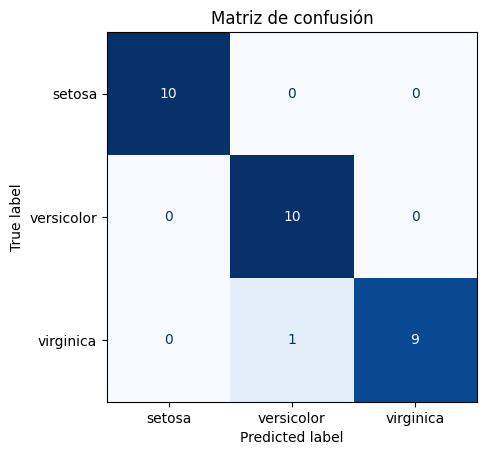

Exactitud: 0.967


In [143]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
ACC = np.mean(Y_pred == Y_test)
print(f"Exactitud: {ACC:.3f}")